In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [156]:
df = pd.read_csv('epa-sea-level.csv', parse_dates=['Year']).dropna()
y = np.array(df['CSIRO Adjusted Sea Level Rise taking 1880 level as base value (mm/year)'])
y = y[-50:]
df

,Year,CSIRO Adjusted Sea Level Rise taking 1880 level as base value (mm/year)
0,1880-03-15,0.000000
1,1881-03-15,0.220472
2,1882-03-15,-0.440945
3,1883-03-15,-0.232283
4,1884-03-15,0.590551
...,...,...
129,2009-03-15,8.586614
130,2010-03-15,8.901575
131,2011-03-15,8.964567
132,2012-03-15,9.326772


In [159]:
x = []

def compute_diff(i) :
    x.append(df['Year'][i].year)

In [160]:
for i in range(134) :
    compute_diff(i)
x = x[-50:]

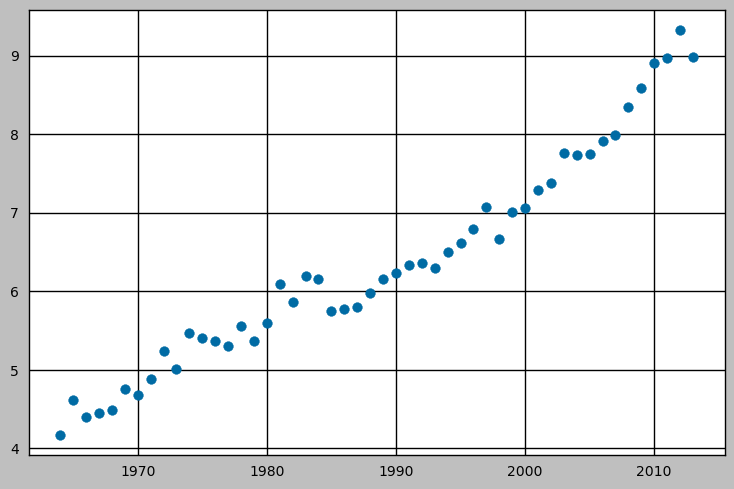

In [163]:
x = np.array(x)
plt.scatter(x,y)

In [165]:
covariance = 0

for i in range(50) :
    covariance += (x[i] - x.mean())*(y[i] - y.mean())

covariance = covariance/50
print(covariance)

18.8119684835


In [167]:
alpha = covariance/x.var()
beta  = y.mean() - alpha*x.mean()

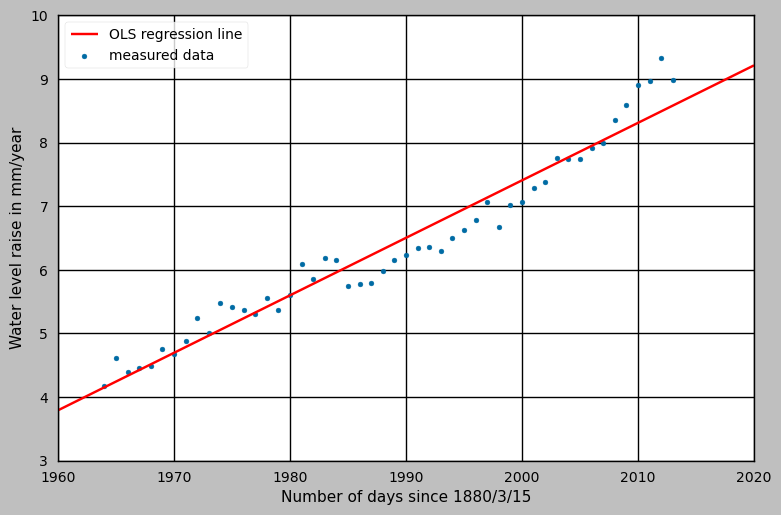

In [172]:
a  =  np.linspace(1870, 2020,100)
plt.style.use('tableau-colorblind10')
plt.plot(a, alpha*a + beta, color = 'red')
plt.xlabel('Number of days since 1880/3/15')
plt.ylabel('Water level raise in mm/year')
plt.scatter(x, y, marker = '.')
plt.xlim(1960,2020)
plt.ylim(3,10)
plt.legend(['OLS regression line', 'measured data'])
plt.show()

In [169]:
print('LINE EQUATION')
print('y =', alpha,'x', beta)


LINE EQUATION
y = 0.09033358215366147 x -173.26139898519583


In [170]:
goal = 750
time = np.linspace(2013,2120,10000)

current = 0
for t in time :
    if current <= goal :
        current = current + (t*alpha+beta)*0.0107
    else :
        year = t
        break
        
print(year)

2078.11601160116
